
# Regression Example
The example below uses a [marketing](https://scikit-learn.org/stable/datasets/toy_dataset.html) dataset,
in order to illustrate a regression activity.

## Workflow
1. Preparation
    1. Load the dataset from a `.csv` file and show a short description
    1. Data preparation, according to background information
    1. Set the __target__ variable, according to background information
    1. Show the two dimensional scatter plots for all the predicting variables with respect to the target
    1. Split the data into *predicting variables* `X` and *target* `y`
        1. here we set the `random_state` variable to make the experiment *repeatable* 
1. First experiment: compute the regression on a single predicting variable
    1. Consider a reduced dataset containing the chosen variable and the target
    1. Fit the `LinearRegression` estimator on the training set
    1. Show the statistical significance of the fitted model
    1. Predict the target for the test set using the *fitted* estimator
    1. Compute the regression coefficients and the quality measures: *Root Mean Squared Error (RMSE)* and *coefficient of determination (r2)*
1. Second experiment: compute the regression considering all the predicting variables
    1. Repeat the steps from 2.2 to 2.5
1. Third experiment: use the `DecisionTreeRegressor` with the entire dataset
    1. Fit the tree using the default hyperparameters, in order to find the 
    maximum depth of the unconstrained tree
    1. Use *cross-validation* to find the optimal *maximum depth* of the tree
    1. Fit the tree with the optmal `max_depth`
    1. Predict and show the *root mean squared error*
1. Fourth experiment: use the `RandomForestRegressor`
    1. Repeat steps from 4.2 to 4.4 (for simplicity, we use the maximum `max_depth` found in 4.1)


In [2]:
# Code source: Claudio Sartori 
# License: BSD 3 clause

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats
from sklearn import datasets, linear_model
from sklearn.metrics import mean_squared_error, r2_score
import pandas as pd
random_state = 94922767 # this will be used to guarantee the repeatability of the experiment

## Load the dataset from a `.csv` file and show a short description

In [3]:
path = "./regression_example.csv"
df = pd.read_csv(path, index_col=0)
df

,F0,F1,F2,F3,F4,F5,F6,F7,response
idx,,,,,,,,,
0,1.509081,-1.049118,1.978885,1.060733,NaN,0.824655,0.819409,-1.157708,214.593802
1,0.644764,0.007172,0.004493,4.168748,-0.622817,1.855366,-0.540468,1.141118,151.951717
2,0.890241,1.080162,0.168031,0.002733,0.522478,0.407804,1.629592,-1.102599,117.280863
3,-0.212410,-1.034267,1.843441,4.486992,-0.610050,0.734101,-0.142660,-0.172119,229.358473
4,-0.827402,-2.048496,-0.066242,1.361695,1.268456,-1.084906,1.986556,0.425511,230.153189
...,...,...,...,...,...,...,...,...,...
838,-1.282938,-0.504848,1.171113,NaN,1.961343,1.332555,-1.149328,-2.325523,43.141579
839,-1.389938,0.558426,0.190860,0.104489,0.539604,0.098193,-1.218202,3.000174,-117.364188
840,-0.059721,-0.293473,NaN,0.490220,-1.614495,1.029973,0.267280,-0.225370,48.715272


## Data Exploration and preparation

##### Show a short description of the columns

In [4]:
df.describe()

,F0,F1,F2,F3,F4,F5,F6,F7,response
count,802.000000,807.000000,812.000000,8.020000e+02,805.000000,808.000000,806.000000,812.000000,813.000000
mean,-0.037473,0.008466,-0.059965,9.616777e-01,-0.093113,0.034653,-0.019928,-0.034976,3.798356
std,1.038115,0.973884,0.991280,1.286476e+00,1.050385,0.957238,0.997345,0.963010,114.189124
min,-3.700229,-2.832440,-4.141473,2.007427e-08,-4.072767,-2.968219,-2.850505,-3.948627,-358.659591
25%,-0.723630,-0.640017,-0.681924,8.725649e-02,-0.802553,-0.625219,-0.689671,-0.662887,-73.823652
50%,-0.032953,0.005693,-0.050789,4.707895e-01,-0.090512,0.051123,-0.014592,-0.049392,-0.159154
75%,0.629368,0.681480,0.587393,1.350123e+00,0.611545,0.689203,0.612939,0.614423,75.487094
max,3.043062,2.945731,2.925432,9.200073e+00,3.024952,3.210373,2.861549,3.000174,422.794685


##### Show the number of rows with nulls

It is computed subtracting the number of rows in the dataset without nulls from the original number of rows

In [5]:
l1 = df.shape[0]
df = df.dropna()
print(l1 - df.shape[0])

273


#### Drop data that are useless or not usable

In [6]:
# I already dropped idx attribute in the read_csv
df.shape

(570, 9)

In [7]:
df.head()

,F0,F1,F2,F3,F4,F5,F6,F7,response
idx,,,,,,,,,
1,0.644764,0.007172,0.004493,4.168748,-0.622817,1.855366,-0.540468,1.141118,151.951717
2,0.890241,1.080162,0.168031,0.002733,0.522478,0.407804,1.629592,-1.102599,117.280863
3,-0.212410,-1.034267,1.843441,4.486992,-0.610050,0.734101,-0.142660,-0.172119,229.358473
4,-0.827402,-2.048496,-0.066242,1.361695,1.268456,-1.084906,1.986556,0.425511,230.153189
5,-0.635465,-1.112850,-0.330580,6.141348,1.914527,0.408895,-0.364722,-0.731382,-261.116572


## Choose the target and split the data into *predicting variables* `X` and *target* `y`

In [8]:
target = df.columns[-1]
vars = df.columns[:-1]

y = df[target]
X = df[vars]

## Show the two dimensional scatter plots for all the predicting variables with respect to the target

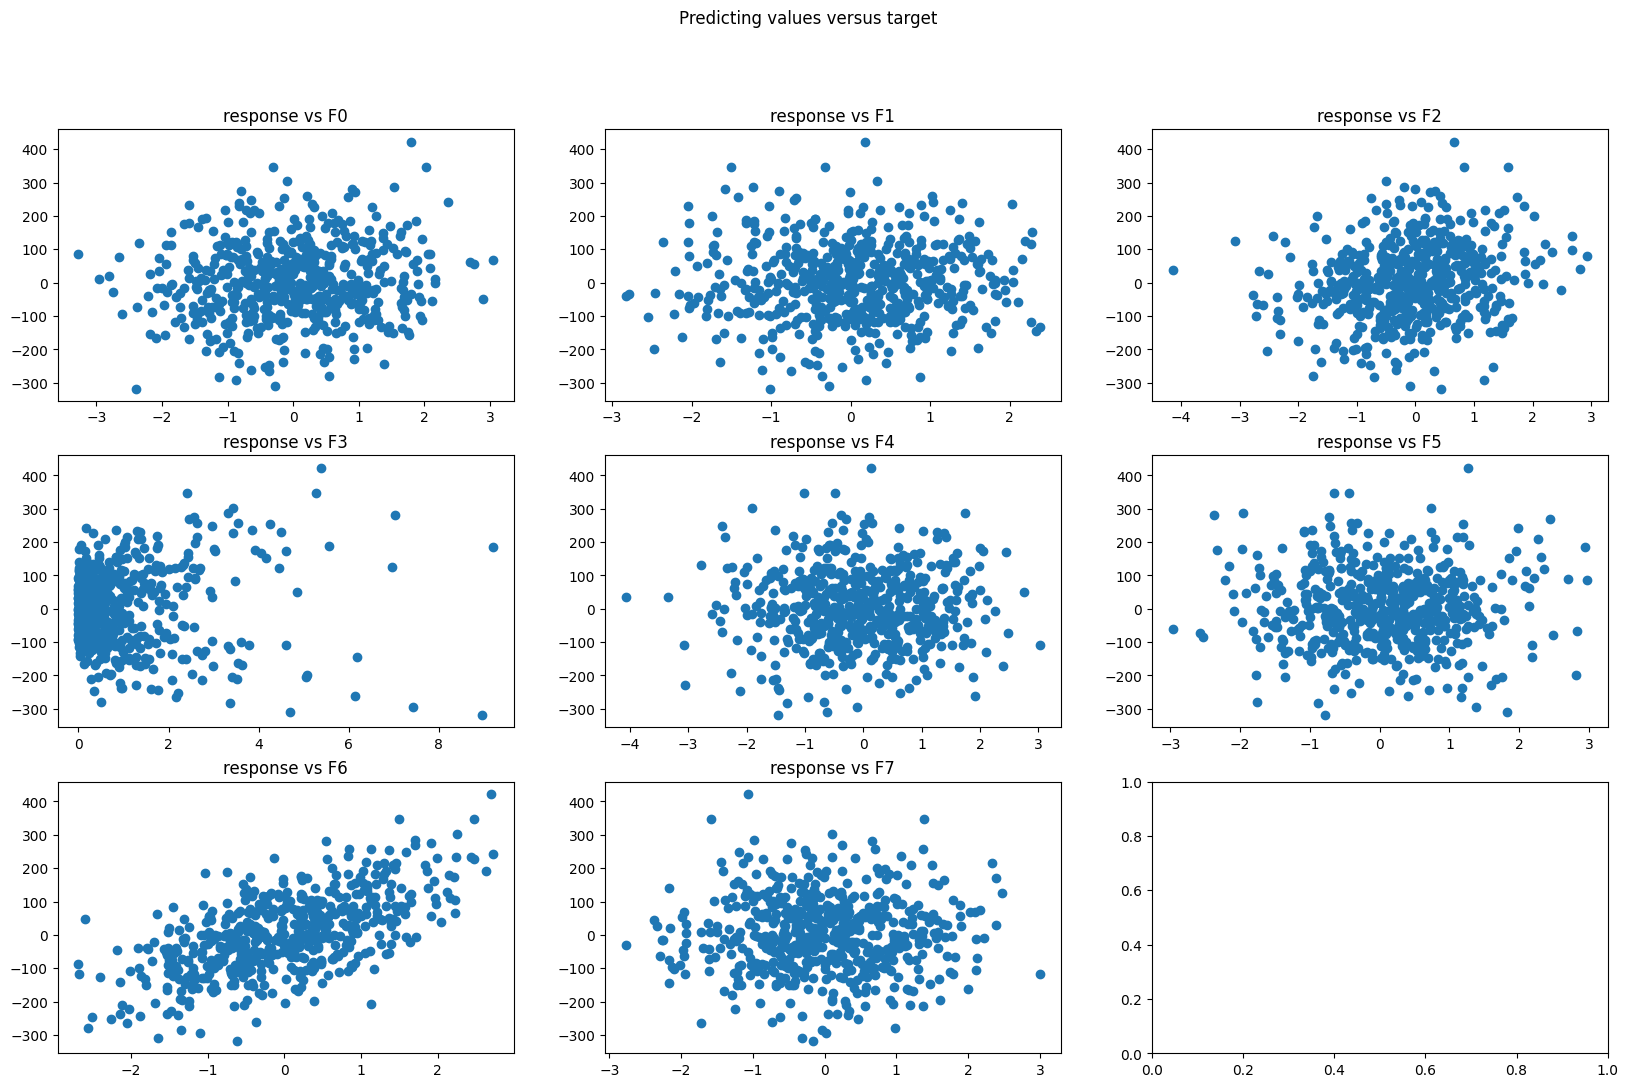

In [9]:
figure, axes = plt.subplots(3, 3, figsize=(20, 12))
axes = axes.flatten()
figure.suptitle("Predicting values versus target")
for i, v in enumerate(vars):
    axes[i].set_title(f"{target} vs {v}")
    axes[i].scatter(X[v], y)
plt.show()

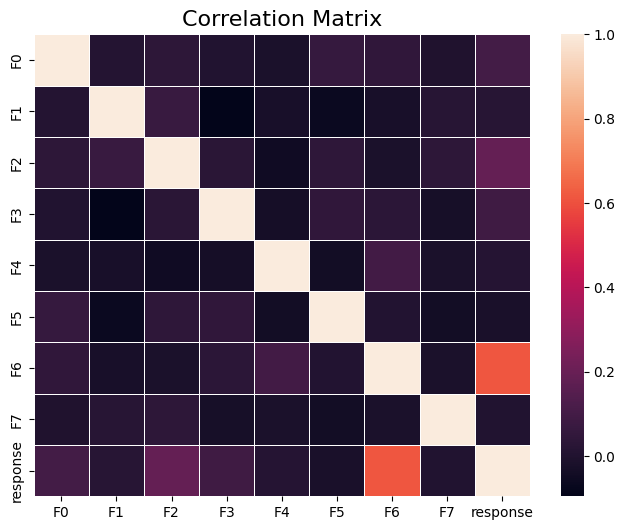

In [11]:
import seaborn as sns
plt.figure(figsize=(8, 6))  # Dimensioni della figura
sns.heatmap(df.corr(), fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=16)
plt.show()

## Split the data into *train* and *test* and show the sizes of the two parts
Here we set the `random_state` variable to make the experiment *repeatable*


In [115]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    random_state=random_state,
    train_size=0.70
)
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(399, 8) (171, 8) (399,) (171,)


## 2. First experiment - univariate linear regression
We choose the variable exhibiting the highest correlation with respect to the target

Consider a reduced dataset containing the chosen variable and the target

In [116]:
corr_to_target = df.corr().iloc[:, -1].sort_values(ascending=False)
max_corr_name = corr_to_target.index[1]
df_reduced = df[[max_corr_name,target]]
df_reduced

,F6,response
idx,,
1,-0.540468,151.951717
2,1.629592,117.280863
3,-0.142660,229.358473
4,1.986556,230.153189
5,-0.364722,-261.116572
...,...,...
835,0.655923,125.436986
836,0.276540,-106.609115
839,-1.218202,-117.364188


### Fit the `linear_model` estimator on the training set and predict the target for the test set using the *fitted* estimator

In [117]:
estimator = linear_model.LinearRegression()
estimator.fit(
    X=np.reshape(X_train[max_corr_name], (-1, 1)), 
    y=y_train
)
y_pred_uni = estimator.predict(np.reshape(X_test[max_corr_name], (-1, 1)))

#### Compute the quality measures

In [118]:
mse_uni = mean_squared_error(y_pred=y_pred_uni, y_true=y_test)
r2s_uni = r2_score(y_pred=y_pred_uni, y_true=y_test)
print(mse_uni,r2s_uni)

7245.711320661929 0.33847681347897574


## Second experiment: compute the regression considering all the predicting variables

### Now we use the entire data in `X_train` and `X_test` for fitting and predicting

In [119]:
estimator = linear_model.LinearRegression()
estimator.fit(
    X=X_train, 
    y=y_train
)
y_pred_multi = estimator.predict(X_test)

### Fit, predict and show the results
Now we see the *regression coefficients* resulting from the fitting. 

In particular, *positive coefficients* indicate that the target *increases* with the variable, *negative coefficients* indicate a *decreasing* trend.

The absolute values of the coefficient cannot be considered directly a measure of importance, due to the possibly different orders of magnitude of the data in the different columns (observe above the outputs of `describe`).

In [120]:
reg_coeffs = pd.DataFrame({"Variable":vars, "Coefficient":estimator.coef_})
reg_coeffs

,Variable,Coefficient
0,F0,9.225329
1,F1,2.794846
2,F2,21.766171
3,F3,3.299594
4,F4,-5.532386
5,F5,-6.002884
6,F6,72.949625
7,F7,-2.675824


#### Compute the quality measures

In [121]:
mse_multi = mean_squared_error(y_pred=y_pred_multi, y_true=y_test)
r2s_multi = r2_score(y_pred=y_pred_multi, y_true=y_test)
print(mse_multi,r2s_multi)

6577.886025358829 0.3994483175642216


## Decision Tree Multivariate Regresson

In [122]:
# Create Decision Tree regression object
from sklearn.tree import DecisionTreeRegressor
tree = DecisionTreeRegressor()

#### Fit the tree with default hyperparameters, and find the maximum depth of the unconstrained tree

In [123]:
tree.fit(X_train, y_train)
print(f"The maximum depth of the full Decision Tree Regressor is {tree.get_depth()}")

The maximum depth of the full Decision Tree Regressor is 22


#### Find the optimal value of the hyperparameter `max_depth` with *cross-validation*
The optimization searches for the *maximum tree depth* guaranteing the smallest mean squared error
At the end, this operation returns also the *fitted best tree* `best_estimator_`

In [132]:
from sklearn.model_selection import GridSearchCV
gsch = GridSearchCV(
    estimator= DecisionTreeRegressor(random_state=random_state),
    param_grid={'max_depth': [*range(1,20)]},
    n_jobs=-1,
    scoring="r2"
)
gsch.fit(X_train, y_train)
best_tree = gsch.best_estimator_
print(f"The optimal maximum depth for the decision tree is {gsch.best_estimator_.max_depth}")

The optimal maximum depth for the decision tree is 2


In [133]:
import math
y_pred_tree = gsch.predict(X_test)
rmse_tree = mean_squared_error(y_pred=y_pred_tree, y_true=y_test)
print(f"Decision Tree Regression - RMSE = {math.sqrt(rmse_tree)}")

Decision Tree Regression - RMSE = 89.82720761576854


#### Show the tree

[Text(0.5, 0.8333333333333334, 'F6 <= 0.493\nsquared_error = 13809.026\nsamples = 399\nvalue = 0.479'),
 Text(0.25, 0.5, 'F6 <= -1.071\nsquared_error = 9807.563\nsamples = 282\nvalue = -38.248'),
 Text(0.125, 0.16666666666666666, 'squared_error = 8030.323\nsamples = 57\nvalue = -115.58'),
 Text(0.375, 0.16666666666666666, 'squared_error = 8359.033\nsamples = 225\nvalue = -18.658'),
 Text(0.75, 0.5, 'F6 <= 1.68\nsquared_error = 11125.64\nsamples = 117\nvalue = 93.823'),
 Text(0.625, 0.16666666666666666, 'squared_error = 8971.137\nsamples = 102\nvalue = 76.235'),
 Text(0.875, 0.16666666666666666, 'squared_error = 9369.573\nsamples = 15\nvalue = 213.419')]

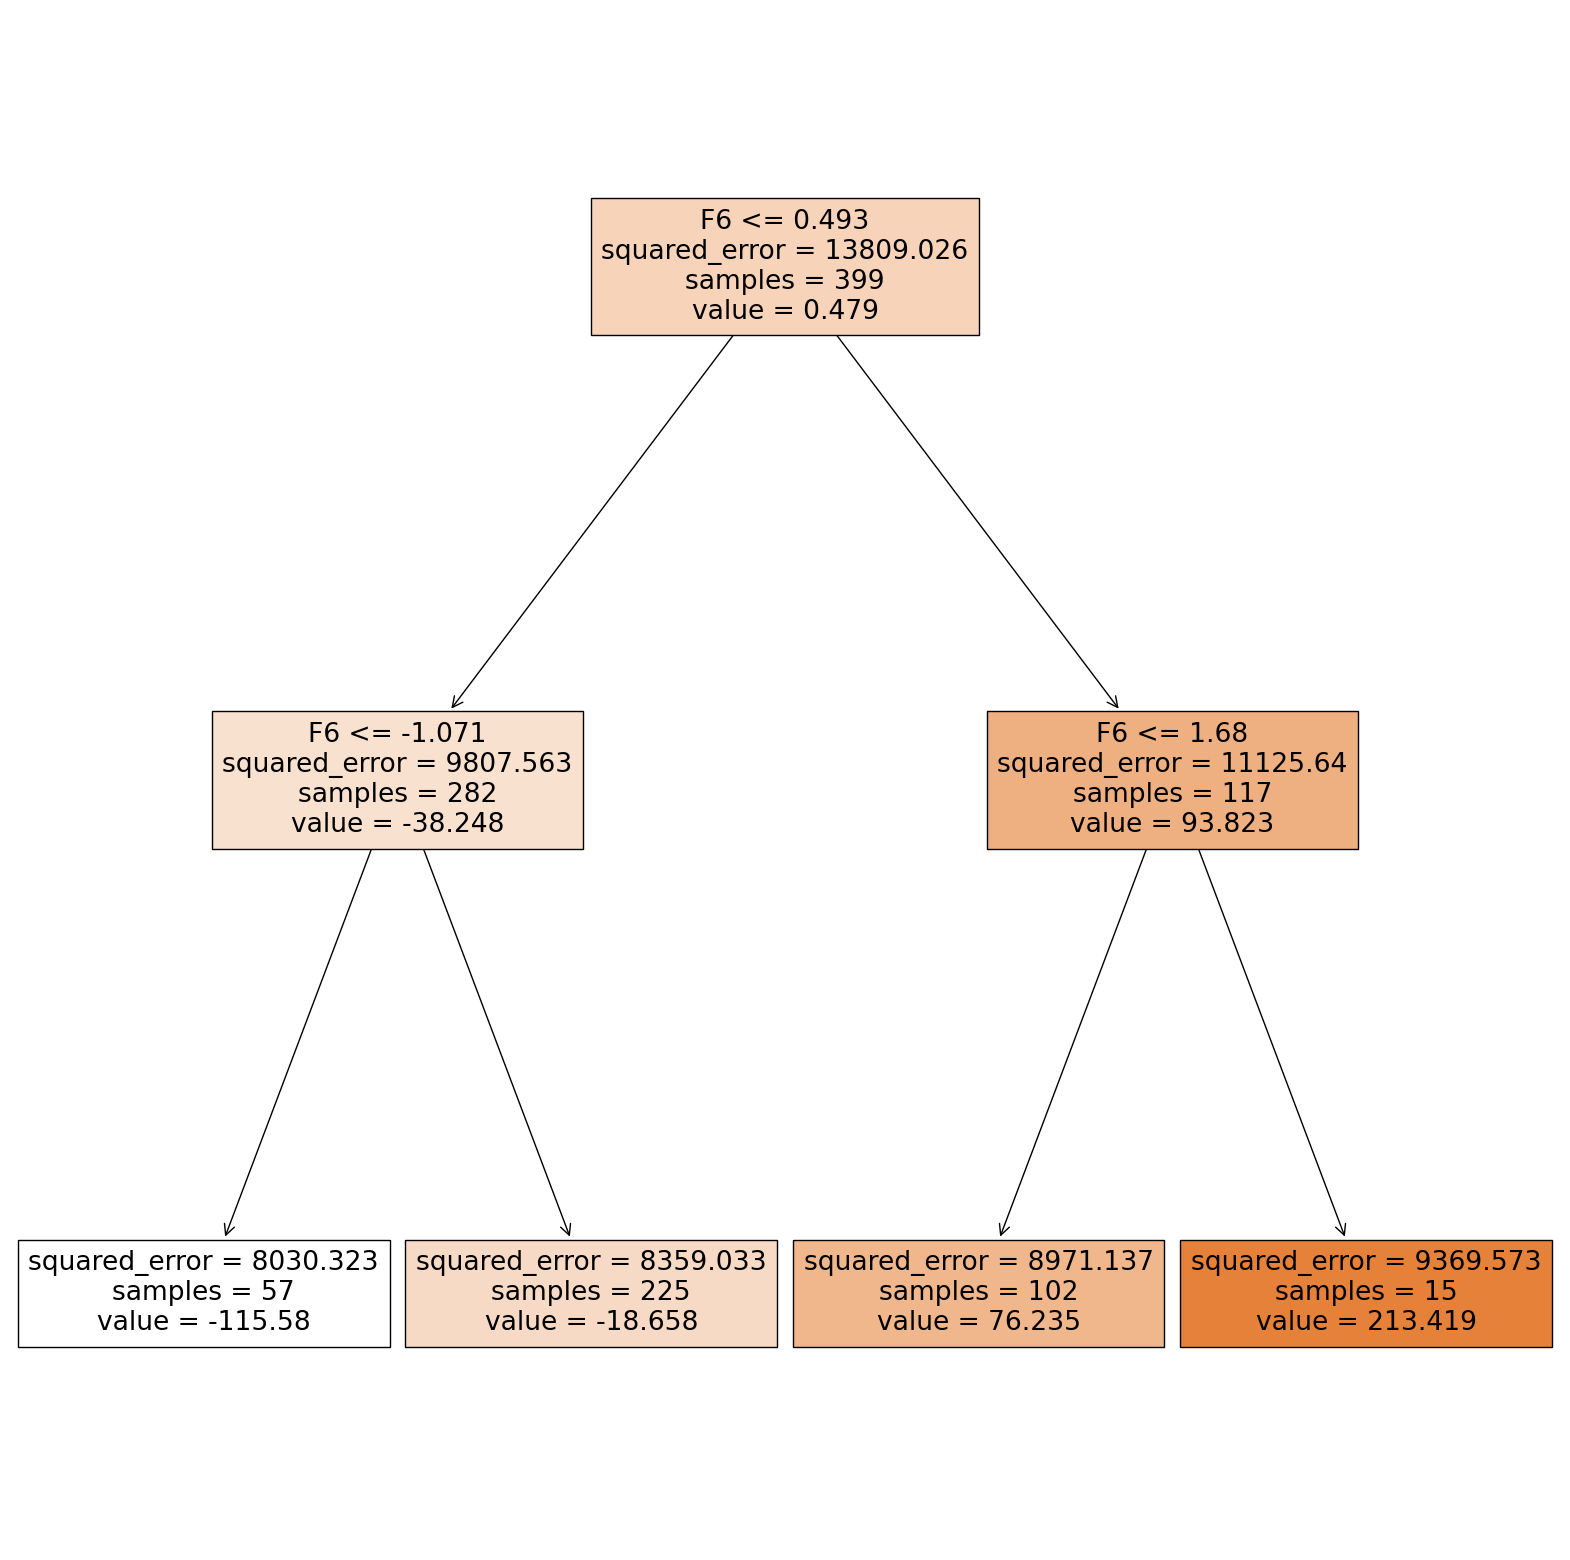

In [134]:
from sklearn.tree import plot_tree
from matplotlib.pyplot import figure

figure(figsize=[20,20])

plot_tree(
    decision_tree=best_tree,
    feature_names=X.columns,
    filled = True
)

## Random Forest Multivariate Regresson

In [135]:
# Create Random Forest regression object
from sklearn.ensemble import RandomForestRegressor
gsch = GridSearchCV(
    estimator= RandomForestRegressor(random_state=random_state),
    param_grid={'max_depth': [*range(1,20)]},
    n_jobs=-1,
    scoring="neg_mean_squared_error"
)
gsch.fit(X_train, y_train)
print(f"The optimal maximum depth for the decision tree is {gsch.best_estimator_.max_depth}")

The optimal maximum depth for the decision tree is 3


In [136]:
y_pred_forest = gsch.predict(X_test)
rmse_forest = mean_squared_error(y_pred=y_pred_forest, y_true=y_test)
print(f"Decision Tree Regression - RMSE = {math.sqrt(rmse_forest)}")

Decision Tree Regression - RMSE = 84.70123424142166


### Plot the prediction of every model, compare it with the real test set, and print the metrics $R^2$ and RMSE 

In [ ]:
dataset = X_test
results = {
    "dt" : y_pred_tree,
    "rf" : y_pred_forest,
    "uni" : y_pred_uni,
    "multi" : y_pred_multi,
    "target" : y_test
}

for k,v in results.items() : 
    dataset[k]=v
dataset = dataset.sort_values(by="F6")

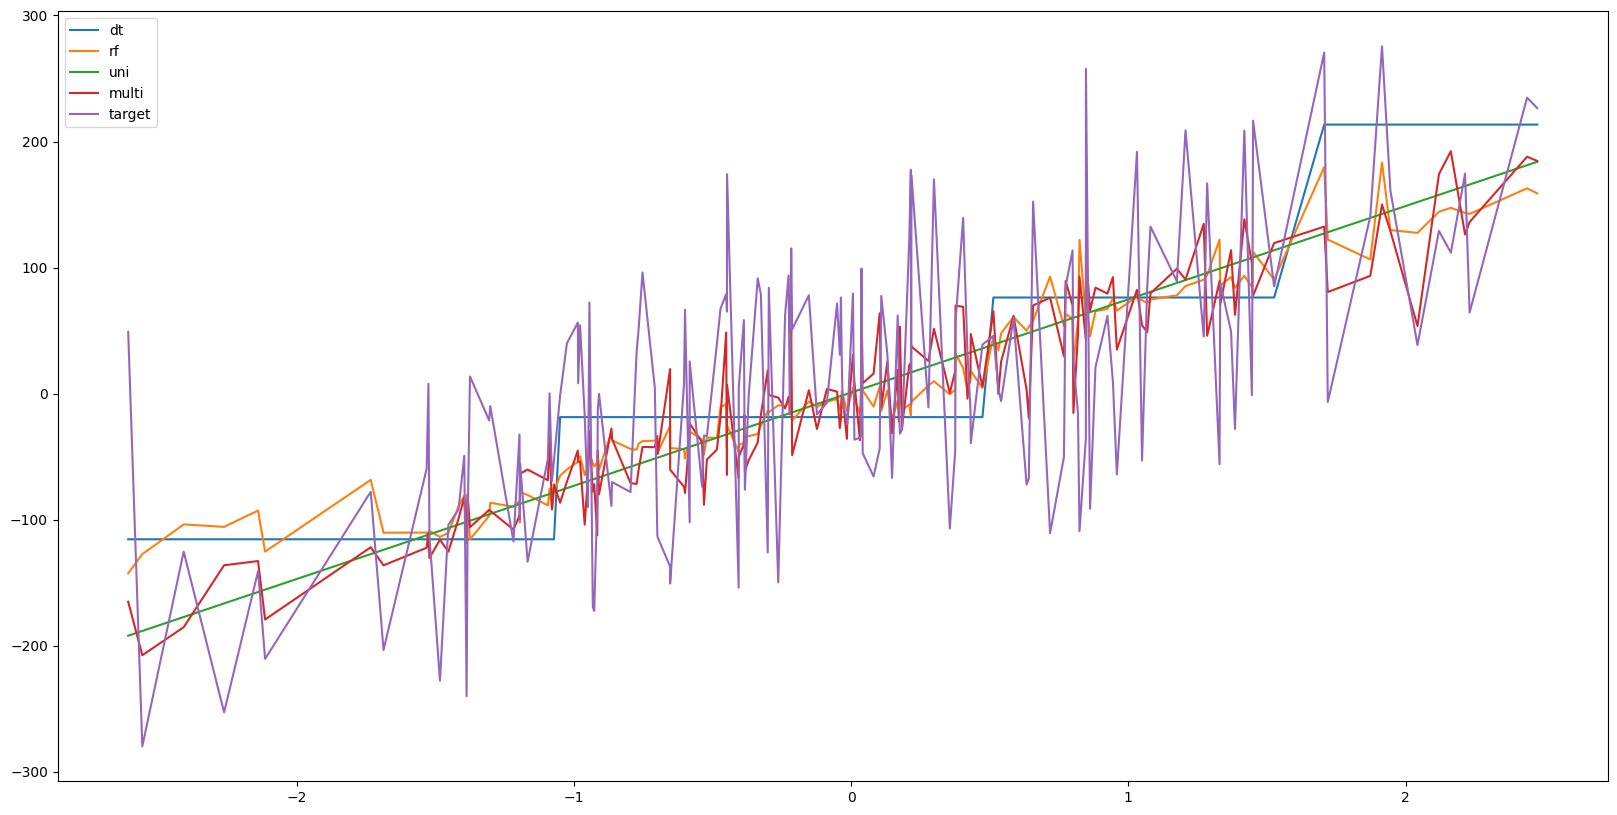

In [173]:
# Compute the struct
plt.figure(figsize=[20,10])

# Use the mask over the different plots
for label in dataset.columns[-5:]:  
    plt.plot(dataset["F6"], dataset[label], label=label)

plt.legend()
plt.show()

In [76]:
pd.DataFrame({
    "model" : ["Linear Univariate on F6", "Linear Multivariate", "Decision Tree Regressor", "Random Forest Regressor"],
    "RMSE" : [ round(math.sqrt(x),2) for x in [mse_uni, mse_multi, rmse_tree, rmse_forest]],
    "R_square" : [round(r2s_uni,3), round(r2s_multi,3), None, None]
})

,model,RMSE,R_square
0,Linear Univariate on F6,83.60,0.362
1,Linear Multivariate,81.10,0.399
2,Decision Tree Regressor,89.83,NaN
3,Random Forest Regressor,82.98,NaN


## Final observations
### Linear regression
The multivariate regression with all the predicting variables available with respect to the univariate regression has 
- lower RMSE 
- higher coefficient of determination 

### Decision Tree and Random Forest regression
- Decision Tree and Random Forest have an RMSE slightly higher than multivariate linear regression



## Control questions
1. observing the multi-variate experiment, what variable has the higher effect on the target?
1. is there a variable having an almost negligible effect on the target?
1. try to repeat the univariate experiment with other columns and comment the results